In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.patches as mpatches
import itertools

from scipy.stats import spearmanr

In [13]:
adata = sc.read('intermediate_results/no_X_no_counts_layer_spectra_adataiPSC_with_pathways_cell_metadata_and_stages.h5ad')
spectra_ = np.load('intermediate_results/spectra_results_iPSC_with_pathways_cell_metadata_and_stages.npy', allow_pickle=True)[()]

In [14]:
factor_loadings = spectra_['factor_loadings']
latent = spectra_['latent_representation']
factor_names_ovelap = adata.uns['SPECTRA_overlap'].index

pathway_names= adata.uns['pathway_names']

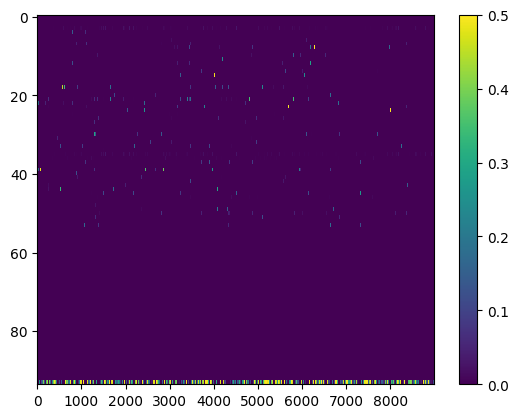

In [15]:


factor_loadings = spectra_['factor_loadings']

plt.imshow(factor_loadings, aspect = 'auto', interpolation ='none')
plt.colorbar()

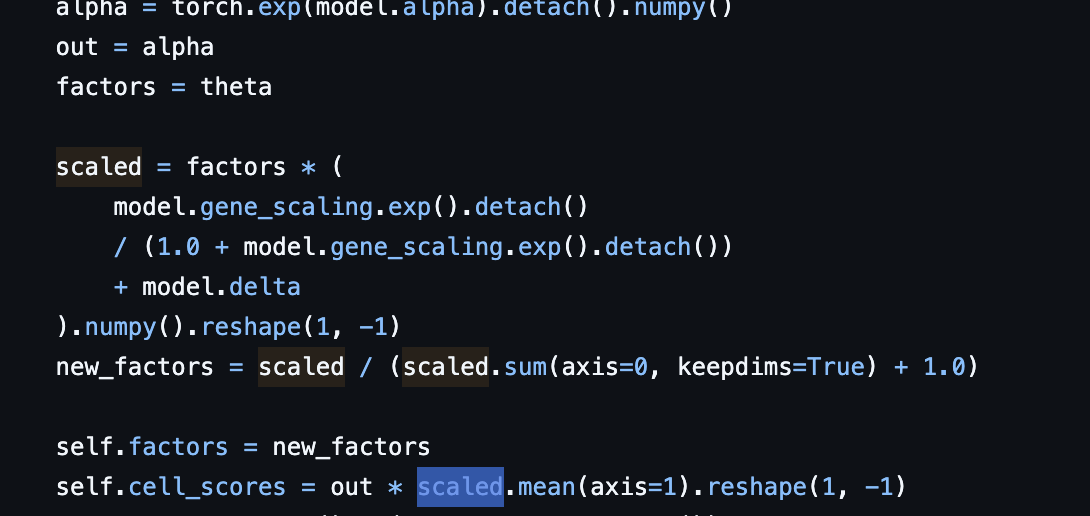
- from https://github.com/dpeerlab/spectra/blob/474a3c708a1fe7336f9368839c8e7058ace12f9d/src/Spectra/Spectra.py
- We use the variance of the latent variables as a pseudo for factor importance,
interestingly the cell_score is not normalised as the paper says, and the variance would all be one if that was the case.

[61 54 56 67 78 82 64 87 38 55 60 83 36 47 35 71 92 80  9 46 59 77 52 91
 72 57 63 90 93 79 62 76 13 16 89 88  1 75 81 19 17 85  2  5 34 29 69 28
  0]
Num duplicate facs 0


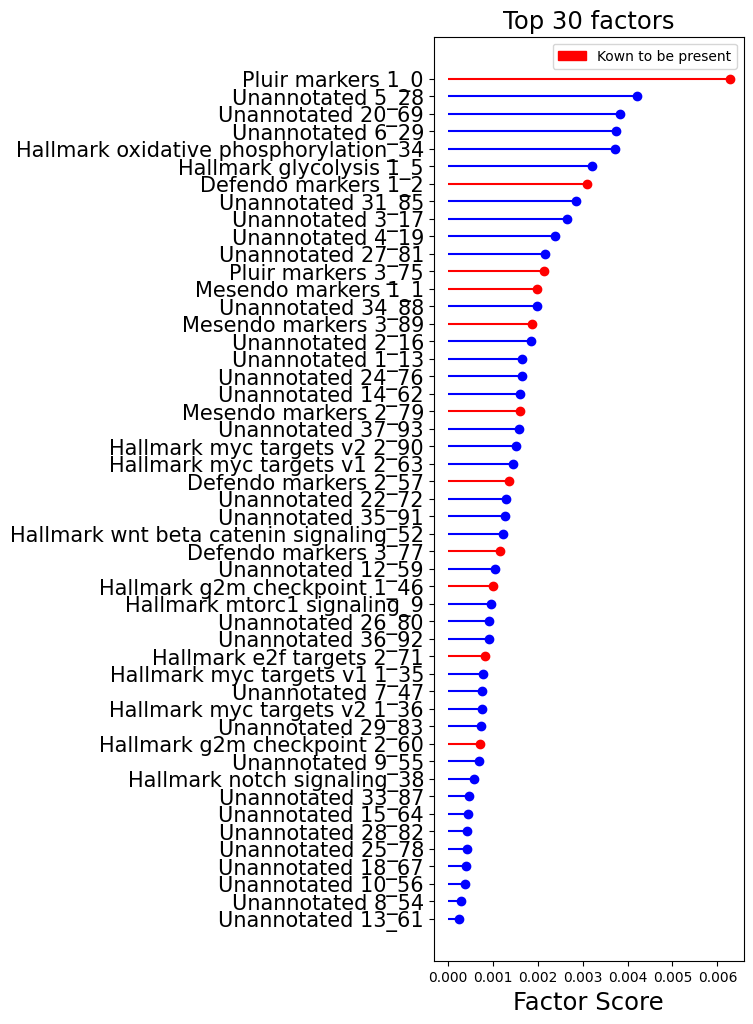

In [16]:

highlighted_pathways = ['pluir_markers', 'mesendo_markers', 'defendo_markers', 'HALLMARK_E2F_TARGETS','respiratory_gene_set','HALLMARK_CHOLESTEROL_HOMEOSTASIS','HALLMARK_G2M_CHECKPOINT','HALLMARK_MITOTIC_SPINDE']


def input_lst_number(input_list):
    # Dictionary to keep track of counts for each element
    count_dict = {}
    
    # List to store the nth occurrence
    nth_occurrence = []
    
    # Iterate through the input list
    for element in input_list:
        count_dict[element] = count_dict.get(element, 0) + 1  # Increment count
        nth_occurrence.append(count_dict[element])           # Append nth occurrence
    return [input_list[i] + ' ' + str(nth_occurrence[i]) for i in range(len(input_list))] 


pathway_names_plot = [i.split('-X-global-X-')[1] for i in adata.uns['SPECTRA_overlap'].index]
pathway_names_plot_digit = [ not i.isdigit() for i in pathway_names_plot]

pathway_names_plot =  np.array(pathway_names_plot) #[pathway_names_plot_digit]

# Changes name of unannotated factors
count = 1
for i in range(len(pathway_names_plot)):
    if pathway_names_plot[i].isnumeric():
        pathway_names_plot[i] = 'Unannotated '  +str(count)
        count += 1


## Adds index to only duplicate factor names 
fac_name_count = {}
pathway_names_plot_new = []
for fac in pathway_names_plot.tolist():
    if np.sum(pathway_names_plot ==fac) > 1:     
        if fac in fac_name_count.keys():
            fac_name_count[fac] += 1           
        else:
            fac_name_count[fac] = 1           
        fac_new = fac +' ' +str(fac_name_count[fac])
    else:
        fac_new = fac
        
    pathway_names_plot_new.append(fac_new)
    
pathway_names_plot =np.array(pathway_names_plot_new)
    

spectra_imp=[]

for path in range(len(pathway_names_plot)):
    string = pathway_names_plot[path].replace('_',' ')
    path_name_ = string[0].upper() + string[1:].lower() 
    spectra_imp.append(path_name_)


factor_importance_only_ann = latent.var(axis =0) #[pathway_names_plot_digit]
index_asc_order = np.argsort(factor_importance_only_ann)[::-1][:50][::-1]
index_asc_order = np.delete(index_asc_order, 7)
print(index_asc_order)
plt.figure(figsize=(4, 12))
count = 1
for i, idx in enumerate(index_asc_order):
    pathway_name = pathway_names_plot[idx]
    color = 'r' if np.any([a in pathway_name  for a in highlighted_pathways ]) else 'b'
    string = pathway_name.replace('_',' ')
    path_name_ = string[0].upper() + string[1:].lower() 
    if path_name_=='Pluir markers':
        path_name_ = 'iPSC markers'
    #path_name_ += str(idx)
    if np.sum(pathway_names_plot == pathway_name)>1:
        path_name_ +=  ' ' + str(count)
        count += 1
        
    if path_name_.isnumeric(): path_name_ = 'Unannotated ' + path_name_
    plt.stem([path_name_+'_'+str(idx)], [factor_importance_only_ann[idx]], markerfmt=color+'o', linefmt=color+'-', orientation='horizontal')


num_dupicate_facs = len(pathway_names_plot[index_asc_order])-len(list(set(pathway_names_plot[index_asc_order])))
print('Num duplicate facs',num_dupicate_facs)


#  plt.stem(np.array(pathway_names_plot)[index_asc_order], factor_importance[index_asc_order], markerfmt='ro', linefmt='b-', orientation='horizontal')
plt.title('Top 30 factors', fontsize =17.5)
plt.xlabel('Factor Score', fontsize =17.5)
plt.tick_params(axis='y', which='major', labelsize=15)
            
red_patch = mpatches.Patch(color='red', label='Kown to be present')
blue_patch = mpatches.Patch(color='blue', label='Not known to be present')

plt.legend(handles=[red_patch])

plt.show()


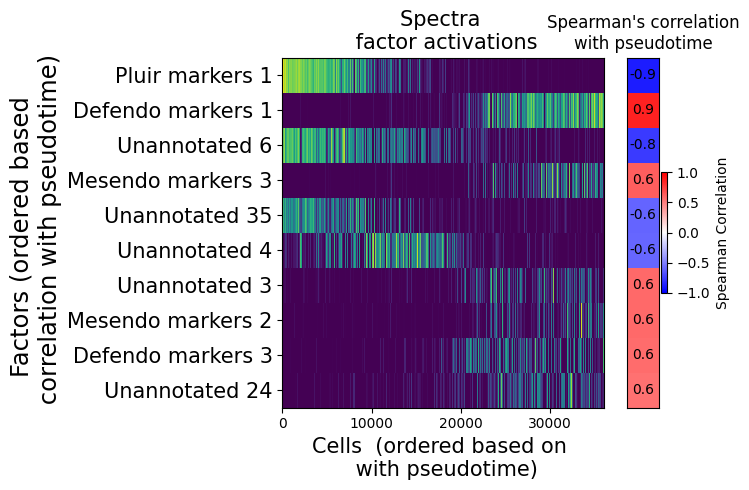

In [17]:
def scale_rows_zero_one(matrix):
    """
    Scales each row of a matrix to be between 0 and 1.
    
    Parameters:
        matrix (np.ndarray): Input 2D array.
    
    Returns:
        np.ndarray: Row-wise scaled matrix.
    """
    min_vals = matrix.min(axis=1, keepdims=True)
    max_vals = matrix.max(axis=1, keepdims=True)
    # Avoid division by zero
    scaled = (matrix - min_vals) / (max_vals - min_vals + 1e-8)
    return scaled


factor_importance = latent.var(axis =0)
learned_activations = np.transpose(latent)
#subset based on top 30 factors 
n_top_fac = 30

index_asc_order = np.argsort(factor_importance)[::-1][:n_top_fac]
learned_activations_n_top_facs = learned_activations[index_asc_order,:]

pathway_names_plot_n_top_facs = [pathway_names_plot[i] for i in index_asc_order]

fac = 2
i = fac  # Index of HEME factor 

ind_sort = np.argsort(adata.obsm['pseudo'])

correlations_ = np.array([np.abs(spearmanr(adata.obsm['pseudo'], row).correlation) for row in learned_activations_n_top_facs])

n_top = 10
subset_indx = np.argsort(correlations_)[::-1][:n_top]
data = learned_activations_n_top_facs[subset_indx, :] # Replace with your actual data

# Index of the row to compare with
pathway_names_plot_subset = [pathway_names_plot_n_top_facs[i].replace('_', ' ') for i in subset_indx]

# Compute Spearman's correlation for each row with the target row

correlations = np.array([spearmanr(adata.obsm['pseudo'], row).correlation for row in data])#np.array([spearmanr(target_row, row).correlation for row in data])

# Plot the data matrix and the Spearman correlation side by side, the tied observations receive the same average rank
fig, axes = plt.subplots(1, 2, figsize=(7.5, 5), gridspec_kw={'width_ratios': [4, 0.5]})

# Plot the data matrix on the left
im = axes[0].imshow(scale_rows_zero_one(data[:,ind_sort]), aspect='auto', cmap='viridis', interpolation='nearest')
axes[0].set_title("Spectra \n factor activations", fontsize = 15)
axes[0].set_xlabel("Cells  (ordered based on \n with pseudotime)", fontsize = 15)
axes[0].set_ylabel(f"Factors (ordered based \n correlation with pseudotime)", fontsize = 17.5)
axes[0].set_yticks([i for i in range(len(pathway_names_plot_subset))], [i.split('[')[0].replace('Hallmark ', '').capitalize() for i in pathway_names_plot_subset], fontsize = 15)

#plt.colorbar(im, ax=axes[0], label='Value')

# Plot the correlations as a single row on the right
correlation_matrix = correlations.reshape(-1, 1)  # Convert to a column vector for plotting
im_corr = axes[1].imshow(correlation_matrix, aspect='auto', cmap='bwr', interpolation='nearest', vmin=-1, vmax=1)
for i in range(correlation_matrix.shape[0]):
    value = np.round(correlation_matrix[i, 0], 1)
    axes[1].text(0, i, f'{value}', ha='center', va='center', color='black', fontsize=10)

axes[1].set_title(f"Spearman's correlation\nwith pseudotime")
axes[1].set_xticks([])
axes[1].set_yticks([])
cbar = plt.colorbar(im_corr, ax=axes[1], label='Spearman Correlation')
# for j, lab in enumerate(correlation_matrix.squeeze()):
#     cbar.ax.text(0, ( j -4.5) / 1.55, np.round(lab,1), ha='center', va='center')
plt.tight_layout()
plt.show()

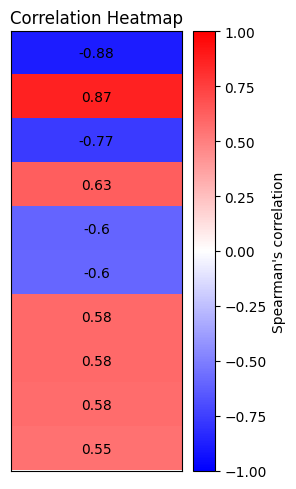

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(3, 5))  # Adjust size as needed

im = ax.imshow(correlation_matrix, aspect='auto', cmap='bwr', vmin=-1, vmax=1)

# Annotate each cell with its value
for i in range(correlation_matrix.shape[0]):
    value = np.round(correlation_matrix[i, 0], 2)
    ax.text(0, i, f'{value}', ha='center', va='center', color='black', fontsize=10)

ax.set_xticks([])  # Remove x-axis ticks
ax.set_yticks([])  # Optional: remove y-axis ticks or set factor names

plt.colorbar(im, ax=ax, label="Spearman's correlation")
plt.title("Correlation Heatmap", fontsize=12)
plt.tight_layout()
plt.show()


0


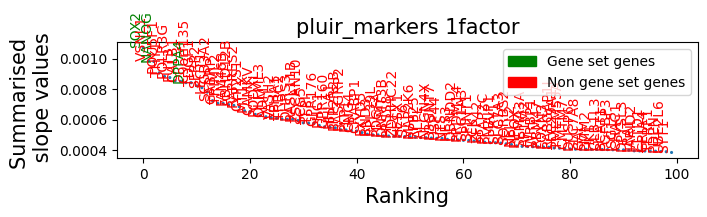

['SOX2', 'VSNL1', 'NANOG', 'POU5F1', 'THY1', 'POLR3G', 'FUT3', 'CALB1', 'DPPA4', 'C9orf135', 'TDGF1', 'SFRP2', 'LECT1', 'SCGB3A2', 'GABRP', 'TRIML2', 'FAM46B', 'ABHD12B', 'RARRES2', 'CYP2S1', 'MT1X', 'CAMKV', 'PODXL', 'OLFML3', 'ADM', 'VASH2', 'EPHA1', 'TRBC2', 'DHRS3', 'RASL11B', 'ZSCAN10', 'SCG5', 'TFPI', 'GPR176', 'PHC1', 'GPR160', 'HHLA1', 'PPP2R2B', 'RASGRP2', 'PLP1', 'GNG4', 'CRABP1', 'FXYD5', 'RND3', 'RPL39L', 'PDGFA', 'DNMT3B', 'PRSS8', 'ZDHHC22', 'HESX1', 'SYT6', 'MAP2K6', 'RPP25', 'ALPL', 'NLGN4X', 'B3GNT7', 'USP44', 'NTS', 'HES3', 'DBNDD2', 'PRDM14', 'SLC1A3', 'SPINT1', 'LCK', 'ZFP42', 'PPAP2C', 'PMAIP1', 'SPRY1', 'SLC7A3', 'SORBS2', 'NELL2', 'PIPOX', 'SEMA3A', 'AP1M2', 'WRBP1', 'RBM47', 'FOXN3', 'RABGAP1L', 'SLC29A1', 'TMEM55A', 'CMTM7', 'DUSP6', 'SLC7A8', 'GAL', 'PMM2', 'HK1', 'GLB1L3', 'BCAT1', 'FGFBP3', 'ISG15', 'CHAC1', 'DPYSL3', 'LRAT', 'JARID2', 'L1TD1', 'GRIA4', 'TERF1', 'PDPN', 'UBE2L6', 'SYT1']
1


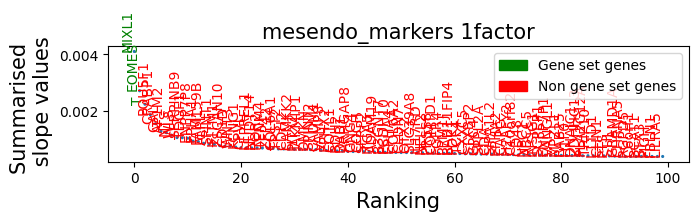

['MIXL1', 'EOMES', 'T', 'POU5F1', 'CRABP1', 'GAL', 'AP1M2', 'NTS', 'WLS', 'SERPINB9', 'TDGF1', 'ENPP7P8', 'EPHA1', 'FAM159B', 'ALPL', 'SPINT1', 'IFITM1', 'ZSCAN10', 'CD1D', 'WNT3', 'KCNG1', 'CPVL', 'LEPREL1', 'NUDT14', 'ROR2', 'TENM4', 'ZFP42', 'COL6A1', 'TPST2', 'CDH2', 'CAMKK2', 'PITX2', 'JAKMIP1', 'DMKN', 'SPINT2', 'CADM1', 'VAMP8', 'EPHX2', 'COTL1', 'BDH2', 'DAB1', 'ARHGAP8', 'GNG4', 'COCH', 'SFRP2', 'ITGA5', 'ADAM19', 'B3GNT7', 'PCDH10', 'EPHA4', 'COL6A2', 'CLDN7', 'OTX2', 'SLC39A8', 'IL17RD', 'NELL2', 'PRSS8', 'COMTD1', 'FGFR4', 'PPM1J', 'RAB11FIP4', 'PDK1', 'TCF4', 'CXXC5', 'STXBP2', 'GPC4', 'SPPL2A', 'CDA', 'SIPA1L2', 'EPHA2', 'CAPG', 'H2AFY2', 'C10orf82', 'CD48', 'NPC1', 'ABCC5', 'INSIG1', 'SCPEP1', 'ENPP7P1', 'VANGL1', 'MPZL1', 'RAB25', 'H1F0', 'DNAJC1', 'ZDHHC13', 'PLA2G12A', 'TRIP10', 'L1TD1', 'CHN1', 'PTS', 'STIL', 'GRAMD1A', 'CHRNA5', 'RGPD5', 'C6orf1', 'BCAT1', 'STX3', 'PIGH', 'FBLN1', 'LILRA5']
2


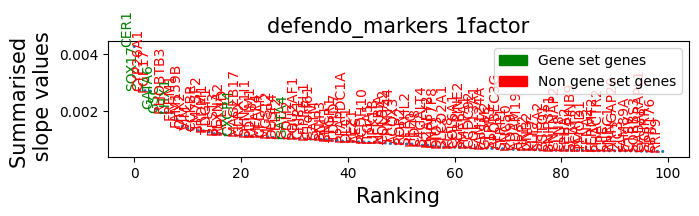

['CER1', 'SOX17', 'CYP26A1', 'FGF17', 'GATA6', 'GSC', 'RHOBTB3', 'LHX1', 'FREM1', 'FAM159B', 'OTX2', 'VIM', 'CCKBR', 'TM7SF2', 'PRDM1', 'TDGF1', 'BEST3', 'PLXNA2', 'ARL4D', 'CXCR4', 'MAGEB17', 'GLRX', 'DYNC1I1', 'PDLIM1', 'MFAP4', 'CFLAR', 'MGST2', 'DUSP4', 'CELF2', 'GATA4', 'CDH2', 'POU2AF1', 'CRIP1', 'LEPREL1', 'C1orf61', 'GATM', 'BNIP3', 'ENC1', 'PTGR1', 'TDRD7', 'PPAPDC1A', 'DLC1', 'FEZ1', 'AES', 'PCDH10', 'ITGA5', 'UPK1B', 'NFKBIA', 'COL5A2', 'TRMT44', 'ACOX3', 'ROR2', 'SERHL2', 'H1F0', 'CD48', 'B4GALT4', 'H2AFY2', 'ENPP7P8', 'DIO3', 'SLCO2A1', 'KLF8', 'COL6A1', 'SERPINE2', 'PMEPA1', 'CCDC92', 'COL13A1', 'FAM124A', 'GPSM2', 'S1PR3', 'APOBEC3G', 'SFRP1', 'UNC50', 'CD99', 'ADAM19', 'NRP2', 'GNB2', 'KLF7', 'SHISA2', 'GSTO1', 'BNIP3P1', 'CNTNAP2', 'CLN8', 'EPHA2', 'SERPINB9', 'BCAT2', 'TMOD1', 'EFNA2', 'FERMT2', 'PHACTR2', 'CPE', 'PNRC1', 'ARHGAP29', 'ZIC3', 'FAM89A', 'CTSV', 'SORBS3', 'GABARAPL1', 'SIGIRR', 'GPR176', 'RRP9']
3


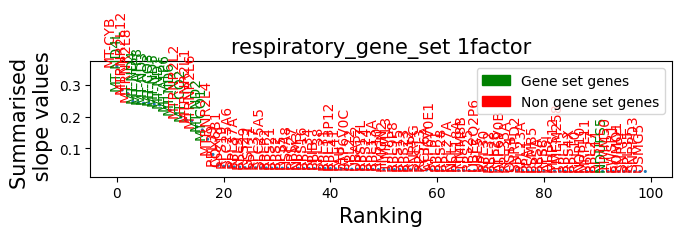

['MT-CYB', 'MT-ND4L', 'MTRNR2L12', 'MTRNR2L8', 'MT-ND4', 'MT-ATP8', 'MT-ND3', 'MT-CO3', 'MT-ND5', 'MT-ND1', 'MT-ATP6', 'MT-ND6', 'MTRNR2L2', 'MT-CO2', 'MTRNR2L1', 'MTRNR2L6', 'MT-ND2', 'MT-CO1', 'MTRNR2L4', 'RPL39', 'COX6B1', 'RPS19', 'SLC25A6', 'RPL37A', 'RPL9', 'RPS29', 'GSTT1', 'RPL37', 'SLC25A5', 'RPLP2', 'RPS21', 'RPS2', 'RPS5', 'HSPA8', 'RPS27', 'NPM3', 'RPS16', 'RPL34', 'PPIB', 'RPL38', 'RPL31', 'RPL13P12', 'RPL41', 'FAU', 'ATP6V0C', 'RPL22', 'UBA52', 'RPS17L', 'RPS24', 'RPL13A', 'RPS10', 'HMGN2', 'TIMM13', 'RPL9P8', 'RPS15', 'RPS23', 'RPL12', 'SNRPG', 'RPS13', 'CCT6A', 'ATP6V0E1', 'RPLP1', 'RPS28', 'RPL27A', 'NCL', 'RPL18A', 'TIMM8B', 'RPS25', 'UBE2Q2P6', 'UBL5', 'RPL30', 'RPL32', 'RPL28', 'ATP6V0B', 'RPL35A', 'OST4', 'SNRPD2', 'RPL23A', 'PPA1', 'PSMB5', 'RPSA', 'RPS8', 'ATP5I', 'MRPS12', 'TMEM258', 'RPL13', 'RPS4X', 'RPL10', 'NOP10', 'MRPL11', 'RPL27', 'RPS11', 'NDUFS5', 'TIMM50', 'EWSR1', 'ROMO1', 'SNRPE', 'RPL35', 'SNRPD3', 'USMG5']
12


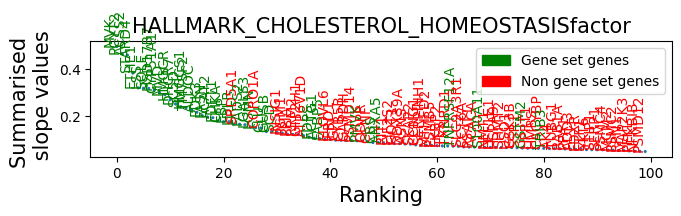

['MVK', 'PCYT2', 'ACSS2', 'STARD4', 'ETHE1', 'LSS', 'SQLE', 'HSD17B7', 'CYP51A1', 'MVD', 'HMGCR', 'DHCR7', 'SC5D', 'HMGCS1', 'TM7SF2', 'ALDOC', 'PDK3', 'FASN', 'ACAT2', 'FDFT1', 'CHKA', 'EBP', 'LDLR', 'SRD5A1', 'FADS2', 'LGALS3', 'LGMN', 'CORO1A', 'CLU', 'GUSB', 'SCD', 'INSIG1', 'PGM1', 'PPIA', 'RRM2', 'GTF2H1', 'ATP6V1D', 'FDPS', 'ACTG1', 'FABP5', 'ELOVL6', 'IFRD1', 'GPI', 'CYB5B', 'GAPDH', 'PSMD14', 'PMVK', 'QDPR', 'CCNF', 'CBS', 'ANXA5', 'RIT1', 'EIF2S2', 'GOT1', 'DDX39A', 'ASNS', 'SKAP2', 'CCNG1', 'SERPINH1', 'MTHFD2', 'PSMB5', 'FKBP2', 'TES', 'TXNRD1', 'TNFRSF12A', 'SLC9A3R1', 'CCT6A', 'PSAT1', 'ACACA', 'S100A11', 'NMT1', 'EEF1E1', 'HSPA9', 'SHMT2', 'USO1', 'GSK3B', 'SSR1', 'GSTM2', 'HPRT1', 'HMBS', 'CACYBP', 'TRIB3', 'AK4', 'TUBG1', 'RAB1A', 'PPA1', 'ADD3', 'FDXR', 'ETF1', 'YKT6', 'STIP1', 'SERP1', 'PSMC4', 'MCM2', 'PSMC2', 'RPN1', 'MAP2K3', 'PFKL', 'NFKBIB', 'PSMD12']
9


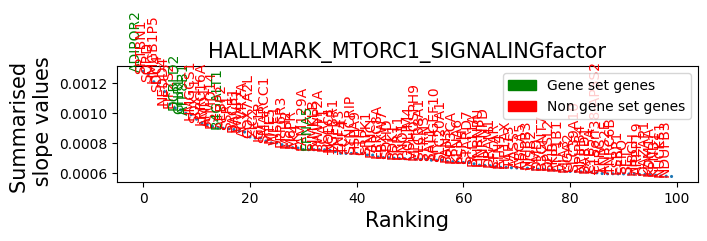

['ADIPOR2', 'SPTBN1', 'SORD', 'HMGB1P5', 'SDC4', 'NEDD4', 'EIF2S2', 'DCBLD2', 'GHRL', 'ATP8B1', 'HMGCS1', 'SOX11', 'LRRC16A', 'AMD1', 'PSMD14', 'B4GALT1', 'AEBP2', 'SSR1', 'BACE1', 'WWP1', 'ACVR2A', 'COX7A2L', 'ZIC2', 'IGF1R', 'SMARCC1', 'MTL5', 'WEE1', 'PPP6R3', 'MSH2', 'M6PR', 'AK4', 'FAM129A', 'EFNA5', 'RIMKLB', 'PWWP2A', 'BCAT1', 'NOLC1', 'TGFBR1', 'ZNF43', 'TCF4', 'SYNCRIP', 'HSPA9', 'CTH', 'SRPK1', 'FANCI', 'LRRC8A', 'FBXW7', 'SDHD', 'PDK1', 'PRR11', 'PNO1', 'GOLIM4', 'MPHOSPH9', 'SLC38A1', 'STRN3', 'SAT1', 'ARHGEF10', 'SLC20A1', 'PAN3', 'PPP3CA', 'KPNA6', 'PSPH', 'STARD7', 'BCL11A', 'HNRNPU', 'HNRNPD', 'DRAM1', 'CFLAR', 'RTN4', 'EIF1AX', 'TAF13', 'AASS', 'ABCA5', 'NPIPB3', 'WSB2', 'DMD', 'B3GNT7', 'DPYSL2', 'PKIB', 'ATP1B1', 'MIA3', 'GGA2', 'SLC39A10', 'NPIPB4', 'BARD1', 'CYB5A', 'C15orf38-AP3S2', 'TFRC', 'ANP32E', 'TNRC6B', 'ESRP1', 'SFPQ', 'SET', 'HIBCH', 'ARPP19', 'DAZAP1', 'KDM1A', 'KPNB1', 'NUCKS1', 'NDUFB3']
46


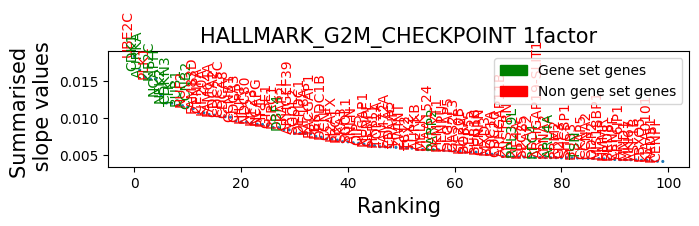

['UBE2C', 'CDK1', 'AURKA', 'PLK1', 'KIF2C', 'NCAPH', 'NEK2', 'CDKN3', 'TTK', 'BUB1', 'NUF2', 'CCNB2', 'FAM83D', 'CENPA', 'KIF20A', 'FAM64A', 'CDCA2', 'CDC25C', 'CDCA8', 'CCNB1', 'CDCA3', 'HJURP', 'NDC80', 'KIF23', 'NCAPG', 'PIF1', 'GTSE1', 'PSRC1', 'DBF4', 'CKAP2L', 'ARHGEF39', 'SGOL2', 'DEPDC1', 'KIF18A', 'RACGAP1', 'PBK', 'DEPDC1B', 'CCNF', 'H2AFX', 'PRC1', 'SKA3', 'SGOL1', 'ANLN', 'OIP5', 'NUSAP1', 'CENPE', 'PRR11', 'TOP2A', 'FAM72A', 'CDCA5', 'TRAIP', 'ZWINT', 'ECT2', 'TPX2', 'AURKB', 'MELK', 'KIAA1524', 'PARP2', 'PKMYT1', 'CENPU', 'DLGAP5', 'GAS2L3', 'KIF20B', 'BORA', 'CEP55', 'BUB1B', 'CENPN', 'MXD3', 'POC1A', 'CDC20', 'ARHGAP11B', 'KNSTRN', 'RPL39L', 'KIF4A', 'SPC25', 'CKAP2', 'RFC4', 'ARHGAP19-SLIT1', 'KPNA2', 'ARL4A', 'RRM2', 'G2E3', 'SHCBP1', 'BUB3', 'TSN', 'CKAP5', 'CCNA2', 'ODF2', 'MIS18BP1', 'HMMR', 'BRD8', 'CENPF', 'ARL6IP1', 'MND1', 'MKI67', 'ASF1B', 'FBXO5', 'KIAA0101', 'RAD51', 'CENPI']
71


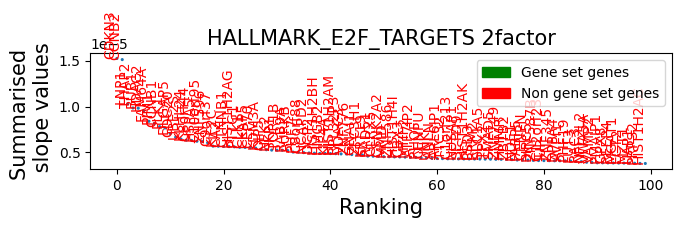

['CDKN3', 'CCNB2', 'LNP1', 'THAP2', 'BUB1', 'HDAC2', 'FAM64A', 'PIM1', 'CCNB1', 'PLK1', 'DLGAP5', 'CDC20', 'UBE2S', 'KLHL24', 'C8orf44', 'HSPA5', 'C10orf95', 'ZNF596', 'C9orf37', 'KIF2C', 'CA2', 'CTNNB1', 'HIST1H2AG', 'PTTG1', 'CLK1', 'CKAP5', 'CEP70', 'KDM3A', 'OIP5', 'NEK2', 'SKP1', 'TOR1B', 'RAB9A', 'AURKB', 'PHF7', 'C8orf88', 'NCAPD2', 'DCP2', 'HIST1H2BH', 'HMGB2', 'KIF4A', 'HIST1H2AM', 'RPL32P3', 'VDAC3', 'ZNF776', 'GNAI1', 'ZFC3H1', 'KRT19', 'RAD51', 'GLRX5', 'CSNK2A2', 'MMD', 'ZNF586', 'HIST1H4I', 'CBX3', 'MTIF2', 'ATF7IP2', 'RHOF', 'CENPU', 'UNK', 'ANLN', 'ARL6IP1', 'TTC32', 'C1orf213', 'NUSAP1', 'SETD9', 'HIST1H2AK', 'PSD3', 'RRM2', 'SLC1A5', 'TPX2', 'SMAD5', 'ZNF749', 'HMMR', 'ZBTB2', 'NDE1', 'FABP5', 'CENPN', 'BIRC5', 'ZNF587B', 'C12orf23', 'JUP', 'ZNF345', 'DPPA4', 'AVPI1', 'PHF19', 'FUT3', 'RAC3', 'NFE2L2', 'VWA5A', 'VAMP2', 'PMAIP1', 'GPX8', 'REEP4', 'MGAT1', 'ECT2', 'MZT1', 'UAP1', 'PRPS2', 'HIST1H2AC']


In [19]:
import torch

def sort_based_on_first_row(matrix):
    sorted_indices = np.argsort(-matrix[0])
    # Rearrange the columns based on the sorted indices
    sorted_matrix = matrix[:, sorted_indices]
    return  sorted_matrix
gene_names = adata.var
num_genes = len(adata.var)

pathways_bool = adata.uns['pathways_9000hvg']
path_uann =  torch.zeros(num_genes)
dict_for_co_ocurrence ={}

for fac in [0,1,2,3,12,9, 46, 71]:
        print(fac)
        factors = [fac]

        slopes_for_all_fac_lst = [adata.uns['SPECTRA_factors'][fac,:]] #scvi_palava.spline_approach(factors = factors)
        #slopes_for_all_fac  = {i:j for i, j  in zip(factors,slopes_for_all_fac_lst)}
        


        data_1 = slopes_for_all_fac_lst[0] #np.quantile(abs(slopes_for_all_fac[fac]), q=0.95, axis=0)
        if fac <50:
            gene_set = pathways_bool[fac][None]
        else: 
            gene_set =np.zeros((1,9000))
        data_1_and_de_no_error = np.concatenate((data_1[None],gene_set ,gene_names.index.to_numpy()[None]), axis=0)
        data_1_and_de_no_error = sort_based_on_first_row(data_1_and_de_no_error)
    
        n_top_genes = 100
    
        y = data_1_and_de_no_error[0][:n_top_genes]
        x = np.array([i for i in range(n_top_genes)])
        top_gene_names = [element for element in data_1_and_de_no_error[2][:n_top_genes]]
    

        plt.figure(figsize=(7.5, 1.5))
        plt.scatter(x, y, s = 5, edgecolor='none')
    
        # plotting pathway genes
        pathway_gene_ind = data_1_and_de_no_error[1][:n_top_genes] == 1
        
        plt.xlabel('Ranking', fontsize =15)
        plt.ylabel('Summarised \n slope values', fontsize =15)
        plt.title(pathway_names_plot[fac].split('[')[0]+ 'factor', fontsize =15)
        
        
        
        top_gene_names = [element.split('_')[1] for element in data_1_and_de_no_error[2][:n_top_genes]]
        for i, txt in enumerate(top_gene_names):
             color = ['r', 'g'][int(data_1_and_de_no_error[1][i])]      
             plt.annotate(txt, (x[i], y[i]), ha = 'right', va = 'bottom', rotation = 90, fontsize = 10, color = color)
        geneset = mpatches.Patch(color='g', label='Gene set genes')
        nongeneset = mpatches.Patch(color='r', label='Non gene set genes')
        if 'Resp' in pathway_names_plot[fac]: # Resp genes have long name
            plt.ylim(0,np.max(y) * 2)
        plt.legend(handles=[geneset, nongeneset])
        plt.show()
        plt.close()
        print(np.array(top_gene_names)[:n_top_genes].tolist())
        dict_for_co_ocurrence[str(pathway_names_plot[fac])] = np.array(top_gene_names)[:n_top_genes].tolist()
        count = 0 
    
        


# Load model

In [20]:
#import packages
import numpy as np
import json 
import scanpy as sc
from collections import OrderedDict
import scipy 
import pandas as pd
import ast

#spectra imports 
import Spectra as spc
from Spectra import Spectra_util as spc_tl
from Spectra import K_est as kst
from Spectra import default_gene_sets
import sys
import os
import re
import timeit
import argparse



In [ ]:


adata = sc.read('data/iPSC_with_pathways_cell_metadata_and_stages.h5ad')

     
pathway_names = adata.uns['pathway_names'].tolist()
print(pathway_names)
num_facs_ann = len(pathway_names)

#adata.X  = adata.X.toarray()       
#adata.X  = adata.X * 1.0

med_libsize = np.median(np.sum(adata.X, axis = 1))
print("Median library size is " + str(med_libsize))
adata_norm = sc.pp.normalize_per_cell(adata, counts_per_cell_after = med_libsize, copy = True)
adata = sc.pp.log1p(adata_norm, copy = True)

I = adata.uns['pathways_9000hvg'].T #adata.uns['Pathways with error']
print(I, I.shape)
gene_array = adata.var.index
annotations ={}
annotations['global'] ={pathway_names[i]:list(gene_array[I[:,i]==1]) for i in range(num_facs_ann)}


start = timeit.default_timer()


model_global = spc.est_spectra(adata = adata, gene_set_dictionary = annotations['global'], # because we do not use the cell types
                                                                                    # we will supply a regular dict
                                                                                    # instead of the nested dict above
                        use_highly_variable = False, cell_type_key =None, #"cell_type_annotations" ,
                        use_weights = True, lam = 0.1, 
                        delta=0.001,kappa = 0.00001, rho = 0.00001, 
                        use_cell_types = False, #set to False to not use the cell type annotations
                        n_top_vals = 25, 
                        clean_gs=True,
                        label_factors=True,
                        num_epochs=0,  #10000, #for demonstration purposes we will only run 2 epochs, we recommend 10,000 epochs
                        L = 94
                       )

['pluir_markers', 'mesendo_markers', 'defendo_markers', 'respiratory_gene_set', 'HALLMARK_ADIPOGENESIS', 'HALLMARK_ALLOGRAFT_REJECTION', 'HALLMARK_ANDROGEN_RESPONSE', 'HALLMARK_ANGIOGENESIS', 'HALLMARK_APICAL_JUNCTION', 'HALLMARK_APICAL_SURFACE', 'HALLMARK_APOPTOSIS', 'HALLMARK_BILE_ACID_METABOLISM', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS', 'HALLMARK_COAGULATION', 'HALLMARK_COMPLEMENT', 'HALLMARK_DNA_REPAIR', 'HALLMARK_E2F_TARGETS', 'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION', 'HALLMARK_ESTROGEN_RESPONSE_EARLY', 'HALLMARK_ESTROGEN_RESPONSE_LATE', 'HALLMARK_FATTY_ACID_METABOLISM', 'HALLMARK_G2M_CHECKPOINT', 'HALLMARK_GLYCOLYSIS', 'HALLMARK_HEDGEHOG_SIGNALING', 'HALLMARK_HEME_METABOLISM', 'HALLMARK_HYPOXIA', 'HALLMARK_IL2_STAT5_SIGNALING', 'HALLMARK_IL6_JAK_STAT3_SIGNALING', 'HALLMARK_INFLAMMATORY_RESPONSE', 'HALLMARK_INTERFERON_ALPHA_RESPONSE', 'HALLMARK_INTERFERON_GAMMA_RESPONSE', 'HALLMARK_KRAS_SIGNALING_DN', 'HALLMARK_KRAS_SIGNALING_UP', 'HALLMARK_MITOTIC_SPINDLE', 'HALLMARK_MTORC1_SIGNA

In [ ]:
model_global.load(fp = 'intermediate_results/spectra_results_iPSC_with_pathways_cell_metadata_and_stages_model.pt')